Dataset link: https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction?select=GUIDE_Train.csv

In [2]:
import pandas as pd

In [3]:
df_train = pd.read_csv('/kaggle/input/microsoft-security-incident-prediction/GUIDE_Train.csv')
df_test = pd.read_csv('/kaggle/input/microsoft-security-incident-prediction/GUIDE_Test.csv')

/tmp/ipykernel_37/461969608.py:2: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('/kaggle/input/microsoft-security-incident-prediction/GUIDE_Test.csv')


In [4]:
combined_df = pd.concat([df_train, df_test], ignore_index=True)

In [5]:
combined_df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13664829 entries, 0 to 13664828
Data columns (total 46 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Id                  int64  
 1   OrgId               int64  
 2   IncidentId          int64  
 3   AlertId             int64  
 4   Timestamp           object 
 5   DetectorId          int64  
 6   AlertTitle          int64  
 7   Category            object 
 8   MitreTechniques     object 
 9   IncidentGrade       object 
 10  ActionGrouped       object 
 11  ActionGranular      object 
 12  EntityType          object 
 13  EvidenceRole        object 
 14  DeviceId            int64  
 15  Sha256              int64  
 16  IpAddress           int64  
 17  Url                 int64  
 18  AccountSid          int64  
 19  AccountUpn          int64  
 20  AccountObjectId     int64  
 21  AccountName         int64  
 22  DeviceName          int64  
 23  NetworkMessageId    int64  
 24  EmailClusterId      fl

In [6]:
columns_to_drop = [
    'Timestamp',
    'Category',
    'MitreTechniques',
    'IncidentGrade',
    'ActionGrouped',
    'ActionGranular',
    'EntityType',
    'EvidenceRole',
    'EmailClusterId',
    'OAuthApplicationId',
    'ThreatFamily',
    'ResourceType',
    'Roles',
    'AntispamDirection',
    'LastVerdict',
    'CountryCode',
    'State',
    'City',
    'Usage'
]

In [7]:
combined_df.drop(columns=columns_to_drop, axis=1, inplace=True)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13664829 entries, 0 to 13664828
Data columns (total 27 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Id                 int64 
 1   OrgId              int64 
 2   IncidentId         int64 
 3   AlertId            int64 
 4   DetectorId         int64 
 5   AlertTitle         int64 
 6   DeviceId           int64 
 7   Sha256             int64 
 8   IpAddress          int64 
 9   Url                int64 
 10  AccountSid         int64 
 11  AccountUpn         int64 
 12  AccountObjectId    int64 
 13  AccountName        int64 
 14  DeviceName         int64 
 15  NetworkMessageId   int64 
 16  RegistryKey        int64 
 17  RegistryValueName  int64 
 18  RegistryValueData  int64 
 19  ApplicationId      int64 
 20  ApplicationName    int64 
 21  FileName           int64 
 22  FolderPath         int64 
 23  ResourceIdName     int64 
 24  OSFamily           int64 
 25  OSVersion          int64 
 26  SuspicionLev

In [8]:
columns_to_drop = ['Id','OrgId','IncidentId','AlertId','DetectorId','DeviceId','AccountSid','AccountObjectId','NetworkMessageId','ApplicationId']
combined_df.drop(columns=columns_to_drop, axis=1, inplace=True)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13664829 entries, 0 to 13664828
Data columns (total 17 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   AlertTitle         int64 
 1   Sha256             int64 
 2   IpAddress          int64 
 3   Url                int64 
 4   AccountUpn         int64 
 5   AccountName        int64 
 6   DeviceName         int64 
 7   RegistryKey        int64 
 8   RegistryValueName  int64 
 9   RegistryValueData  int64 
 10  ApplicationName    int64 
 11  FileName           int64 
 12  FolderPath         int64 
 13  ResourceIdName     int64 
 14  OSFamily           int64 
 15  OSVersion          int64 
 16  SuspicionLevel     object
dtypes: int64(16), object(1)
memory usage: 1.7+ GB


In [9]:
combined_df.head()

,AlertTitle,Sha256,IpAddress,Url,AccountUpn,AccountName,DeviceName,RegistryKey,RegistryValueName,RegistryValueData,ApplicationName,FileName,FolderPath,ResourceIdName,OSFamily,OSVersion,SuspicionLevel
0,6,138268,27,160396,673934,453297,153085,1631,635,860,3421,289573,117668,3586,5,66,NaN
1,43,138268,360606,160396,23032,24887,153085,1631,635,860,3421,289573,117668,3586,5,66,NaN
2,298,138268,360606,68652,673934,453297,153085,1631,635,860,3421,289573,117668,3586,5,66,Suspicious
3,2,138268,360606,13,673934,453297,153085,1631,635,860,3421,289573,117668,3586,5,66,Suspicious
4,74,138268,360606,160396,592,479,153085,1631,635,860,3421,289573,117668,3586,5,66,NaN


In [10]:
combined_df.isnull().sum()

AlertTitle                  0
Sha256                      0
IpAddress                   0
Url                         0
AccountUpn                  0
AccountName                 0
DeviceName                  0
RegistryKey                 0
RegistryValueName           0
RegistryValueData           0
ApplicationName             0
FileName                    0
FolderPath                  0
ResourceIdName              0
OSFamily                    0
OSVersion                   0
SuspicionLevel       11570865
dtype: int64

In [12]:
combined_df.dropna(subset=['SuspicionLevel'], inplace=True)
combined_df.head()

,AlertTitle,Sha256,IpAddress,Url,AccountUpn,AccountName,DeviceName,RegistryKey,RegistryValueName,RegistryValueData,ApplicationName,FileName,FolderPath,ResourceIdName,OSFamily,OSVersion,SuspicionLevel
2,298,138268,360606,68652,673934,453297,153085,1631,635,860,3421,289573,117668,3586,5,66,Suspicious
3,2,138268,360606,13,673934,453297,153085,1631,635,860,3421,289573,117668,3586,5,66,Suspicious
6,2,138268,360606,3306,673934,453297,153085,1631,635,860,3421,289573,117668,3586,5,66,Suspicious
8,4,0,360606,160396,673934,453297,153085,1631,635,860,3421,0,1694,3586,5,66,Suspicious
10,4,138268,360606,160396,673934,453297,4872,1631,635,860,3421,289573,117668,3586,5,66,Suspicious


In [13]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2093964 entries, 2 to 13664822
Data columns (total 17 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   AlertTitle         int64 
 1   Sha256             int64 
 2   IpAddress          int64 
 3   Url                int64 
 4   AccountUpn         int64 
 5   AccountName        int64 
 6   DeviceName         int64 
 7   RegistryKey        int64 
 8   RegistryValueName  int64 
 9   RegistryValueData  int64 
 10  ApplicationName    int64 
 11  FileName           int64 
 12  FolderPath         int64 
 13  ResourceIdName     int64 
 14  OSFamily           int64 
 15  OSVersion          int64 
 16  SuspicionLevel     object
dtypes: int64(16), object(1)
memory usage: 287.6+ MB


In [14]:
combined_df.drop_duplicates(inplace=True)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 419382 entries, 2 to 13664794
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   AlertTitle         419382 non-null  int64 
 1   Sha256             419382 non-null  int64 
 2   IpAddress          419382 non-null  int64 
 3   Url                419382 non-null  int64 
 4   AccountUpn         419382 non-null  int64 
 5   AccountName        419382 non-null  int64 
 6   DeviceName         419382 non-null  int64 
 7   RegistryKey        419382 non-null  int64 
 8   RegistryValueName  419382 non-null  int64 
 9   RegistryValueData  419382 non-null  int64 
 10  ApplicationName    419382 non-null  int64 
 11  FileName           419382 non-null  int64 
 12  FolderPath         419382 non-null  int64 
 13  ResourceIdName     419382 non-null  int64 
 14  OSFamily           419382 non-null  int64 
 15  OSVersion          419382 non-null  int64 
 16  SuspicionLevel     4193

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le = LabelEncoder()

combined_df['SuspicionLevel_label'] = le.fit_transform(combined_df['SuspicionLevel'])
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 419382 entries, 2 to 13664794
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   AlertTitle            419382 non-null  int64 
 1   Sha256                419382 non-null  int64 
 2   IpAddress             419382 non-null  int64 
 3   Url                   419382 non-null  int64 
 4   AccountUpn            419382 non-null  int64 
 5   AccountName           419382 non-null  int64 
 6   DeviceName            419382 non-null  int64 
 7   RegistryKey           419382 non-null  int64 
 8   RegistryValueName     419382 non-null  int64 
 9   RegistryValueData     419382 non-null  int64 
 10  ApplicationName       419382 non-null  int64 
 11  FileName              419382 non-null  int64 
 12  FolderPath            419382 non-null  int64 
 13  ResourceIdName        419382 non-null  int64 
 14  OSFamily              419382 non-null  int64 
 15  OSVersion           

In [17]:
combined_df.to_csv('SIEM_data.csv')

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

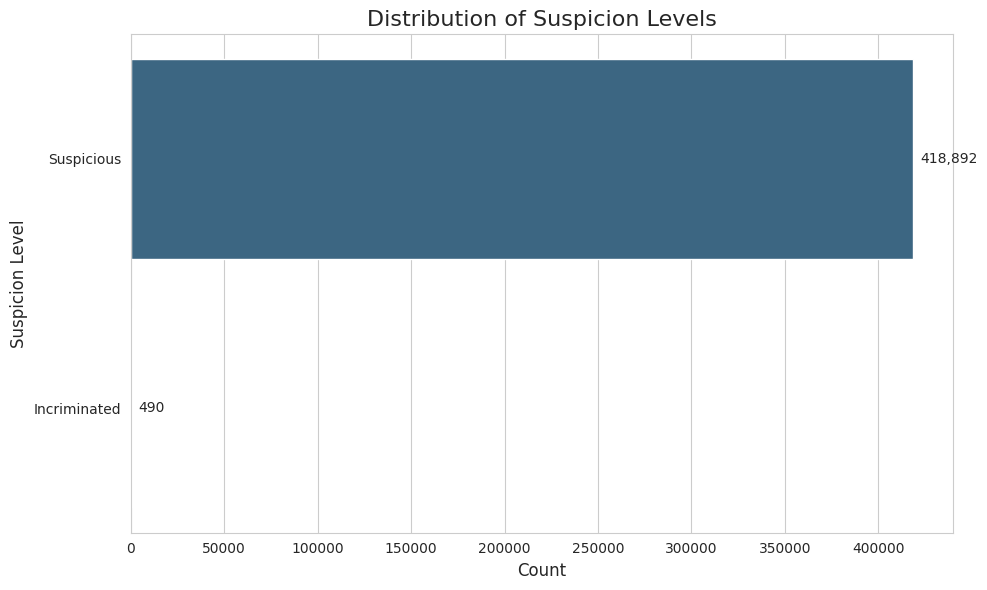

In [21]:
# 1. Distribution of 'SuspicionLevel'
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=combined_df,
    y='SuspicionLevel',
    order=combined_df['SuspicionLevel'].value_counts().index,
    palette='viridis'
)

# Add count labels to the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.title('Distribution of Suspicion Levels', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Suspicion Level', fontsize=12)
plt.tight_layout()
plt.show()

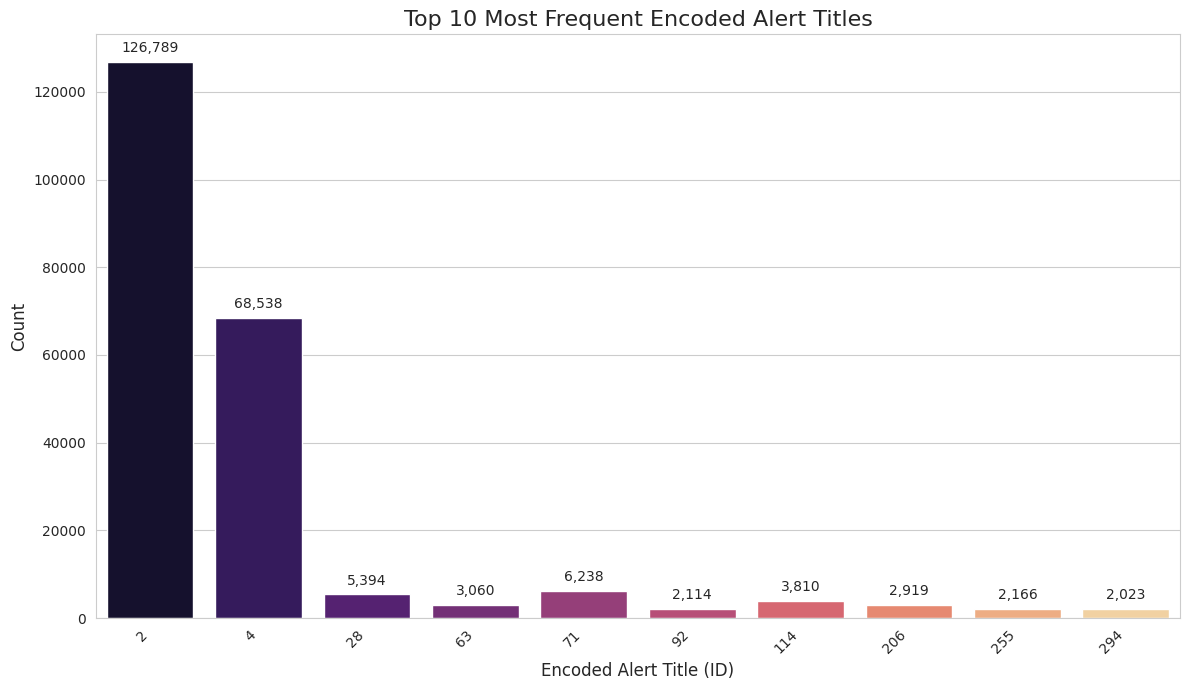

In [22]:
# 2. Top 10 Most Frequent Alert Titles
# Calculate value counts and select the top 10
top_10_alerts = combined_df['AlertTitle'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_10_alerts.index,
    y=top_10_alerts.values,
    palette='magma'
)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.title('Top 10 Most Frequent Encoded Alert Titles', fontsize=16)
plt.xlabel('Encoded Alert Title (ID)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

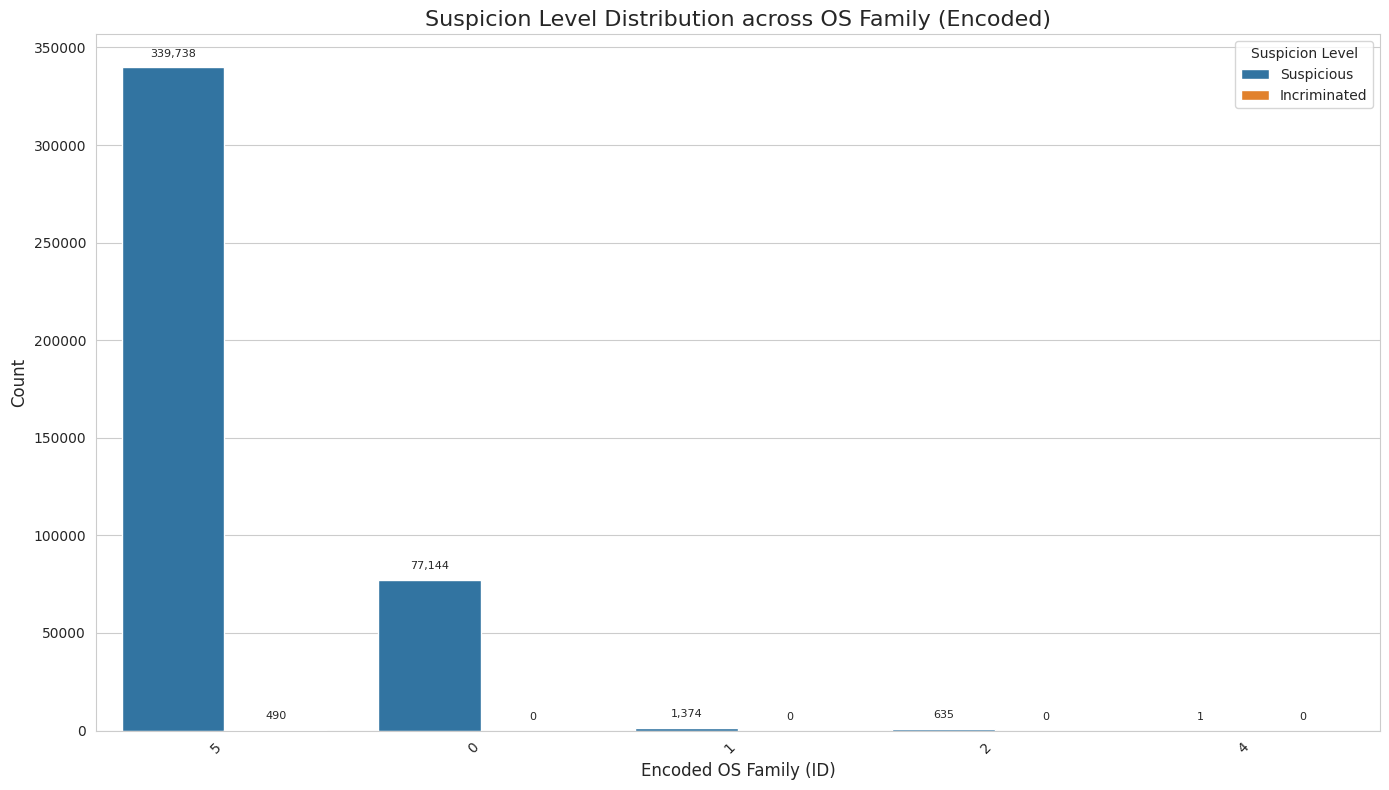

In [23]:
# 3. Suspicion Level Distribution by OS Family
# Assuming 'OSFamily' has a manageable number of unique values.

plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=combined_df,
    x='OSFamily',
    hue='SuspicionLevel',
    palette='tab10',
    order=combined_df['OSFamily'].value_counts().index # Order by overall frequency of OSFamily
)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=8)

plt.title('Suspicion Level Distribution across OS Family (Encoded)', fontsize=16)
plt.xlabel('Encoded OS Family (ID)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Suspicion Level')
plt.tight_layout()
plt.show()

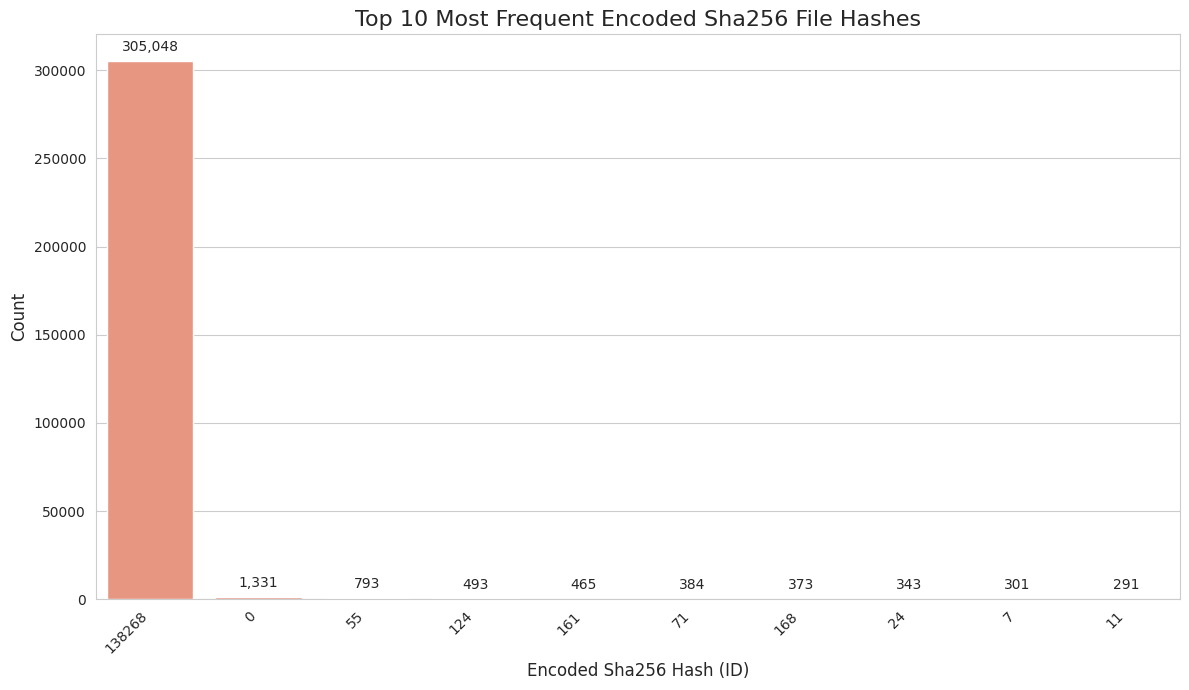

In [24]:
 # 1. Top 10 Most Frequent Sha256 Hashes
# Assuming Sha256 is the encoded file hash column
top_10_sha256 = combined_df['Sha256'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_10_sha256.index.astype(str), # Convert index to string for plotting
    y=top_10_sha256.values,
    palette='Reds_d'
)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.title('Top 10 Most Frequent Encoded Sha256 File Hashes', fontsize=16)
plt.xlabel('Encoded Sha256 Hash (ID)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

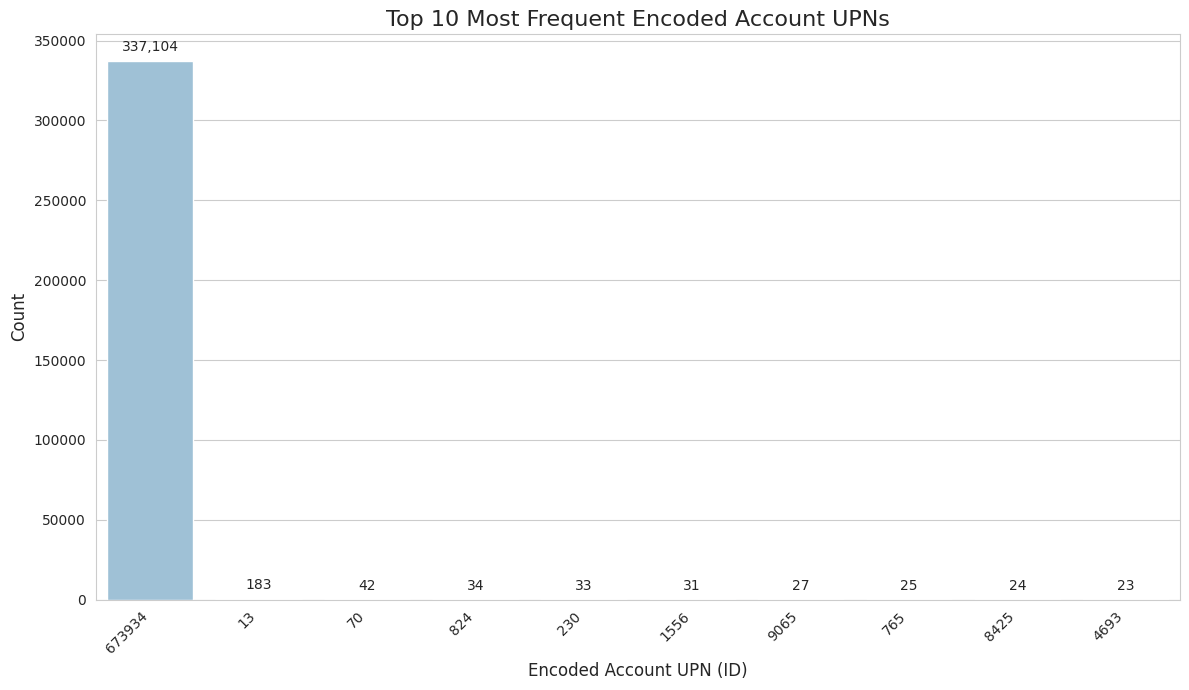

In [25]:
# 2. Top 10 Most Frequent AccountUpn
# Assuming AccountUpn is the encoded user principal name/account ID
top_10_accounts = combined_df['AccountUpn'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_10_accounts.index.astype(str),
    y=top_10_accounts.values,
    palette='Blues_d'
)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.title('Top 10 Most Frequent Encoded Account UPNs', fontsize=16)
plt.xlabel('Encoded Account UPN (ID)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

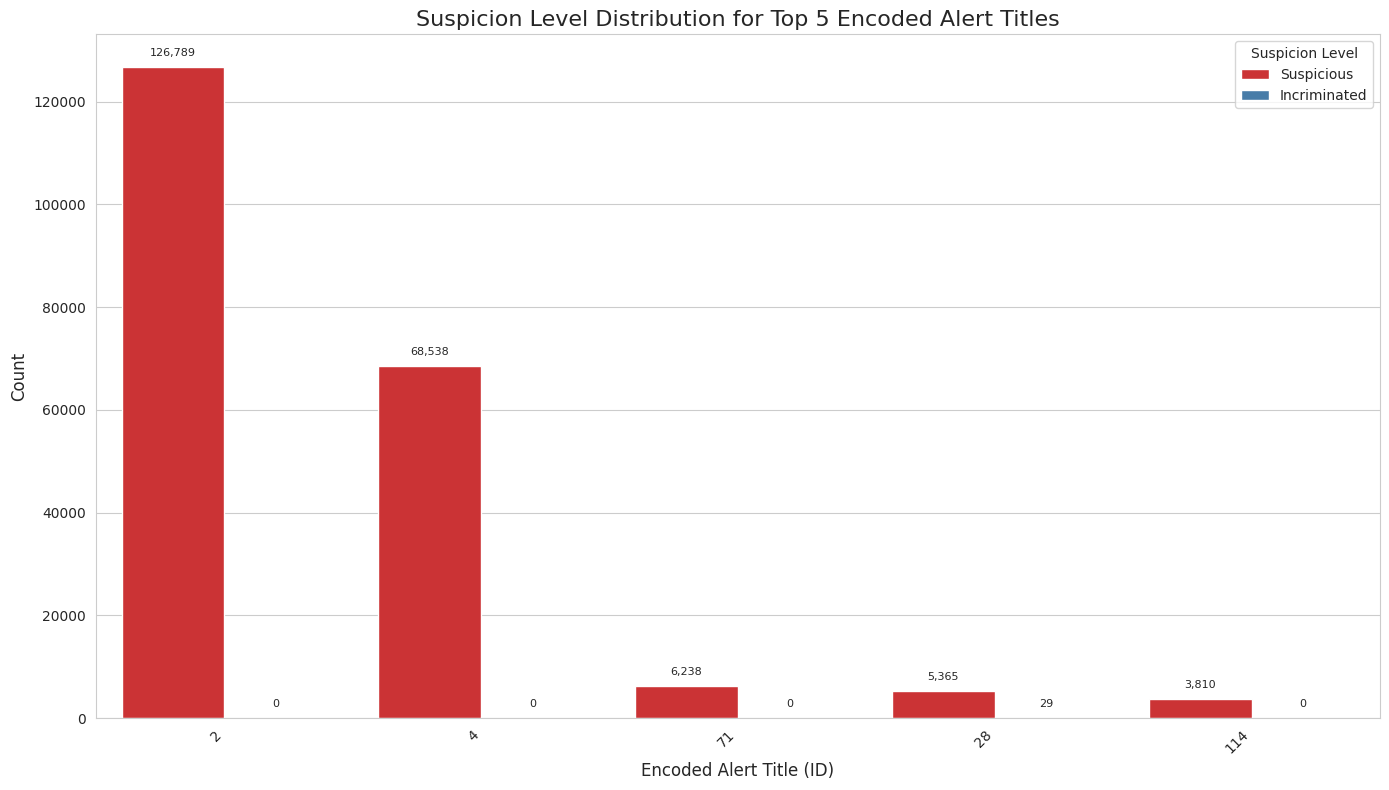

In [26]:
# 3. Suspicion Level Distribution for Top 5 Alert Titles

# Get the top 5 alert titles
top_5_alert_titles = combined_df['AlertTitle'].value_counts().nlargest(5).index

# Filter the DataFrame to include only these top 5 alerts
df_top_alerts = combined_df[combined_df['AlertTitle'].isin(top_5_alert_titles)]

plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df_top_alerts,
    x='AlertTitle',
    hue='SuspicionLevel',
    palette='Set1',
    order=top_5_alert_titles # Ensure the order is by overall frequency
)

# Add count labels on top of the bars (Optional, can clutter the graph)
# You might want to remove this loop if the plot is too dense.
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=8)

plt.title('Suspicion Level Distribution for Top 5 Encoded Alert Titles', fontsize=16)
plt.xlabel('Encoded Alert Title (ID)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Suspicion Level')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


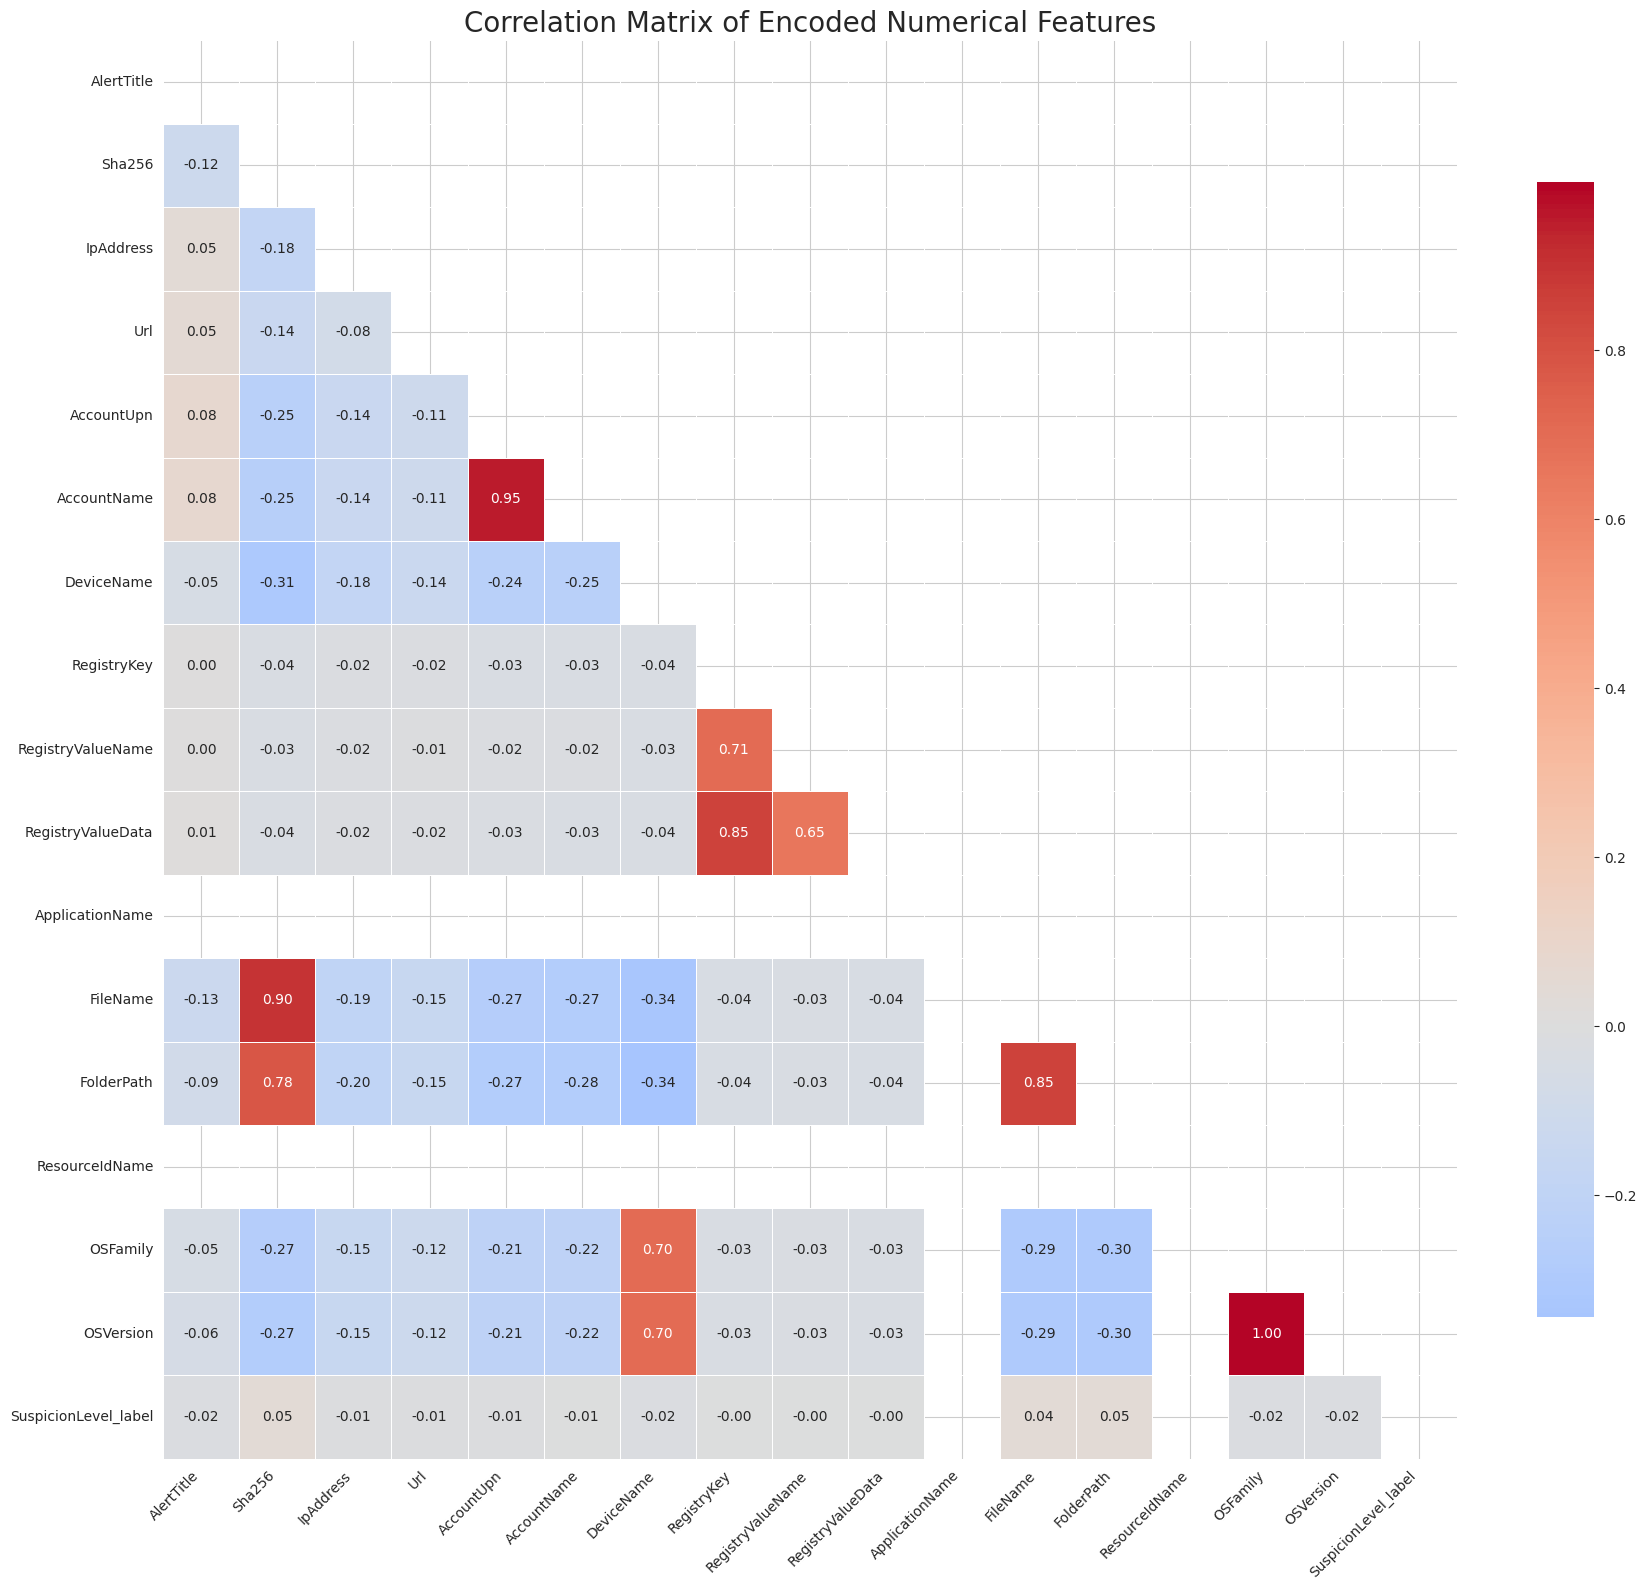

In [27]:
numerical_df = combined_df.select_dtypes(include=['int64'])
correlation_matrix = numerical_df.corr()
mask = np.triu(correlation_matrix)

plt.figure(figsize=(18, 16)) # Set a large figure size for readability
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,              # Show the correlation values on the heatmap
    fmt=".2f",               # Format the annotation to two decimal places
    cmap='coolwarm',         # Use a diverging colormap
    center=0,                # Center the colormap at zero
    linewidths=.5,           # Add lines to separate cells
    cbar_kws={"shrink": .8}  # Shrink the color bar a bit
)

plt.title('Correlation Matrix of Encoded Numerical Features', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()